# Heart Disease Prediction with Machine Learning

This notebook builds a reproducible machine-learning workflow for predicting **HeartDisease** using demographic, clinical, and exercise-test features.

The workflow includes:

1. Data loading and initial quality checks  
2. Exploratory data analysis  
3. One-hot encoding and stratified train/test splitting  
4. Cross-validation model comparison  
5. Final soft-voting ensemble training  
6. Test-set evaluation with ROC, Precision-Recall, and confusion matrix plots  
7. Model interpretability using permutation importance and SHAP

> **Important:** This notebook is designed for educational and research purposes. It should not be used as a stand-alone clinical decision tool.

## 1. Environment Setup

The following cell imports the required libraries, sets global plotting preferences, and defines a fixed random seed so that the results are reproducible.

In [73]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.ensemble import  GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from lightgbm import LGBMClassifier
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier, VotingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    average_precision_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TARGET_COL = "HeartDisease"

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "font.size": 11,
})

## 2. Load the Dataset

The dataset is expected to be stored as `heart.csv` in the same directory as this notebook.

Each row represents one patient record. The target variable is `HeartDisease`, where:

- `0` means **No Heart Disease**
- `1` means **Heart Disease**

In [74]:
DATA_PATH = Path("heart.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "The file 'heart.csv' was not found. "
        "Please place heart.csv in the same directory as this notebook and run the notebook again."
    )

df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape[0]} rows and {df.shape[1]} columns")
display(df.head())

Dataset shape: 918 rows and 12 columns


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


## 3. Initial Data Quality Check

Before modeling, it is important to inspect the structure of the dataset, the data types, missing values, duplicate rows, and class distribution.

In [75]:
df.info()

quality_summary = pd.DataFrame({
    "Data Type": df.dtypes.astype(str),
    "Missing Values": df.isna().sum(),
    "Missing %": (df.isna().mean() * 100).round(2),
    "Unique Values": df.nunique(),
})

display(quality_summary)

print(f"Duplicate rows: {df.duplicated().sum()}")

if TARGET_COL in df.columns:
    target_distribution = (
        df[TARGET_COL]
        .value_counts(normalize=True)
        .rename("Proportion")
        .mul(100)
        .round(2)
        .to_frame()
    )
    target_distribution["Count"] = df[TARGET_COL].value_counts()
    display(target_distribution)

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


,Data Type,Missing Values,Missing %,Unique Values
Age,int64,0,0.0,50
Sex,str,0,0.0,2
ChestPainType,str,0,0.0,4
RestingBP,int64,0,0.0,67
Cholesterol,int64,0,0.0,222
FastingBS,int64,0,0.0,2
RestingECG,str,0,0.0,3
MaxHR,int64,0,0.0,119
ExerciseAngina,str,0,0.0,2
Oldpeak,float64,0,0.0,53


Duplicate rows: 0


,Proportion,Count
HeartDisease,,
1,55.34,508
0,44.66,410


## 4. Exploratory Data Analysis

This section provides a compact visual overview of the dataset.

The goal is not to prove causality, but to understand patterns that may help the predictive models:

- Balance of the target classes  
- Distribution of numerical features  
- Relationship between categorical features and heart disease  
- Correlation structure among numerical variables

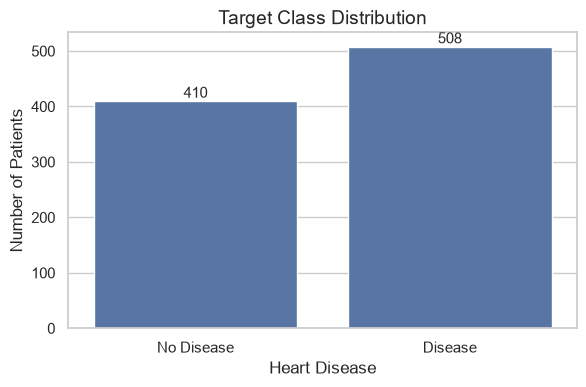

In [76]:
# Target distribution
target_labels = {0: "No Disease", 1: "Disease"}

plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x=TARGET_COL)
ax.set_title("Target Class Distribution")
ax.set_xlabel("Heart Disease")
ax.set_ylabel("Number of Patients")
ax.set_xticklabels([target_labels.get(int(t.get_text()), t.get_text()) for t in ax.get_xticklabels()])

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

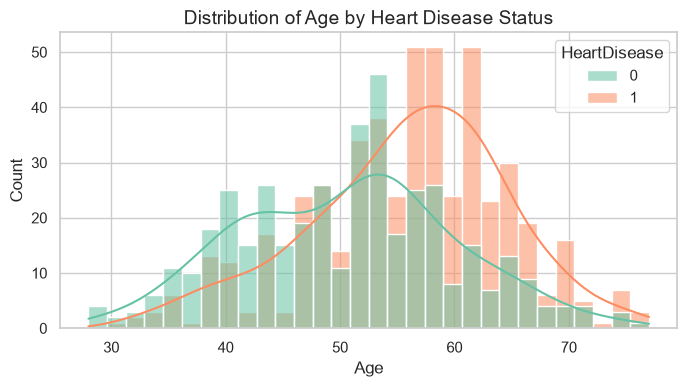

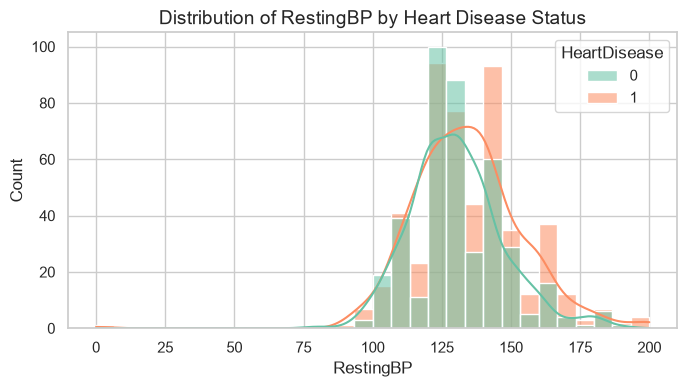

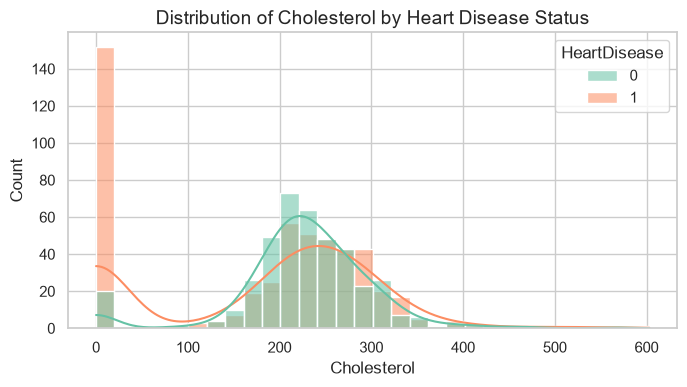

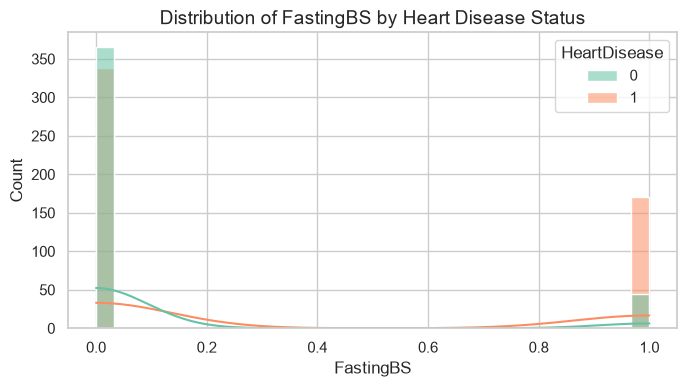

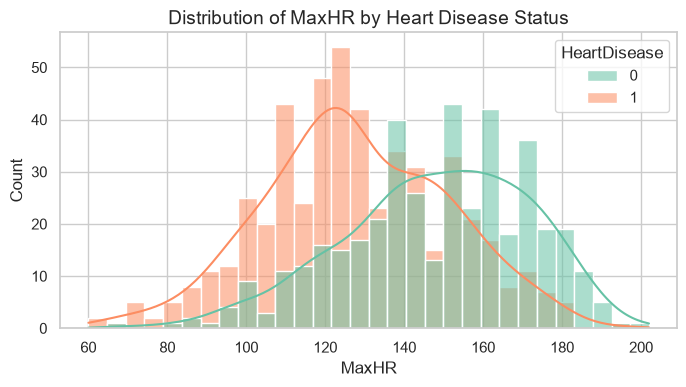

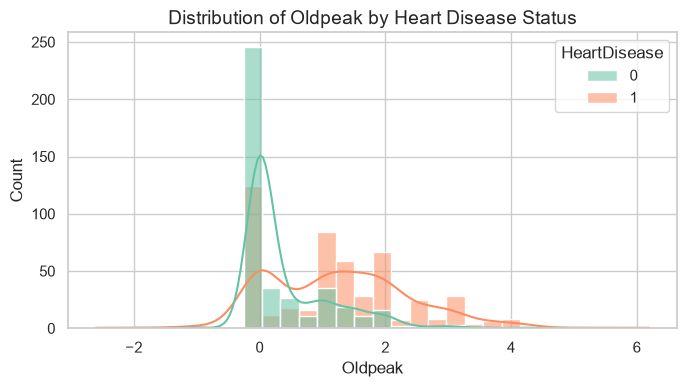

In [77]:
# Numerical feature distributions by target
numeric_features = df.select_dtypes(include=np.number).columns.drop(TARGET_COL, errors="ignore").tolist()

for feature in numeric_features:
    plt.figure(figsize=(7, 4))
    sns.histplot(
        data=df,
        x=feature,
        hue=TARGET_COL,
        kde=True,
        bins=30,
        alpha=0.55,
        palette="Set2",
    )
    plt.title(f"Distribution of {feature} by Heart Disease Status")
    plt.xlabel(feature)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

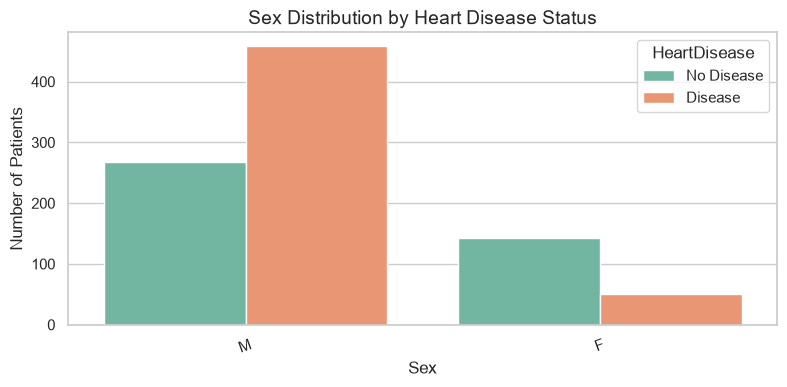

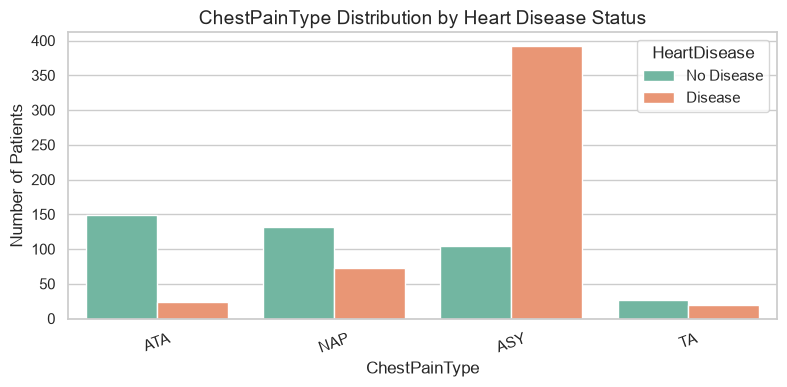

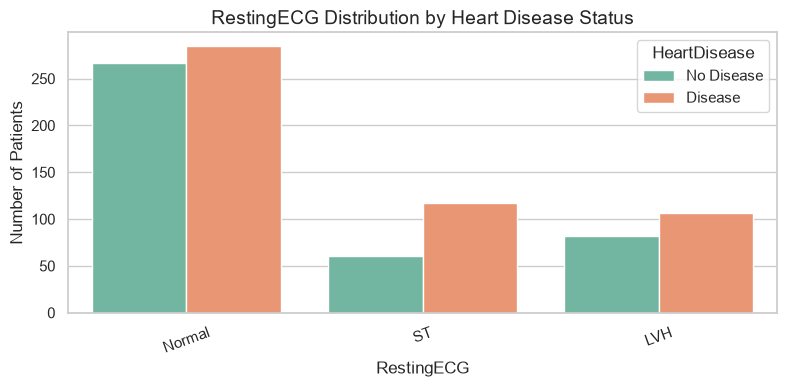

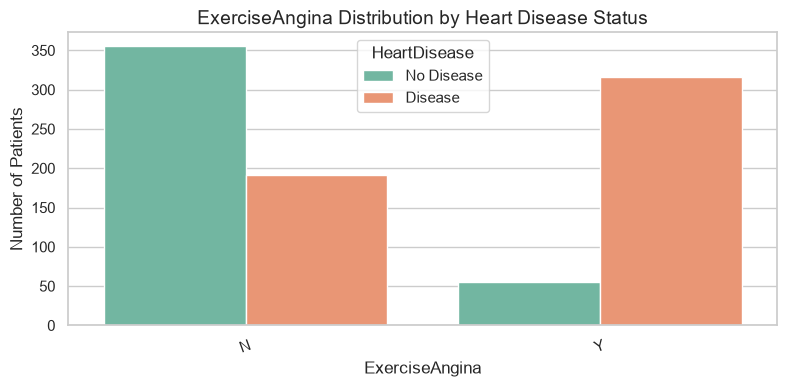

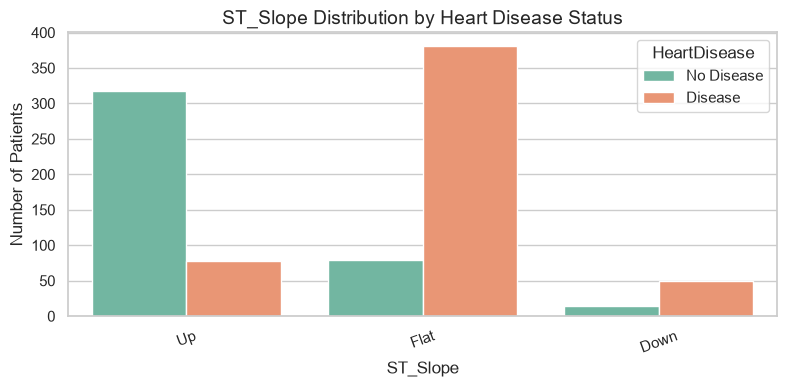

In [78]:
# Categorical feature distributions by target
categorical_features = df.select_dtypes(include=["object", "category"]).columns.tolist()

for feature in categorical_features:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=feature, hue=TARGET_COL, palette="Set2")
    plt.title(f"{feature} Distribution by Heart Disease Status")
    plt.xlabel(feature)
    plt.ylabel("Number of Patients")
    plt.legend(title="HeartDisease", labels=["No Disease", "Disease"])
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

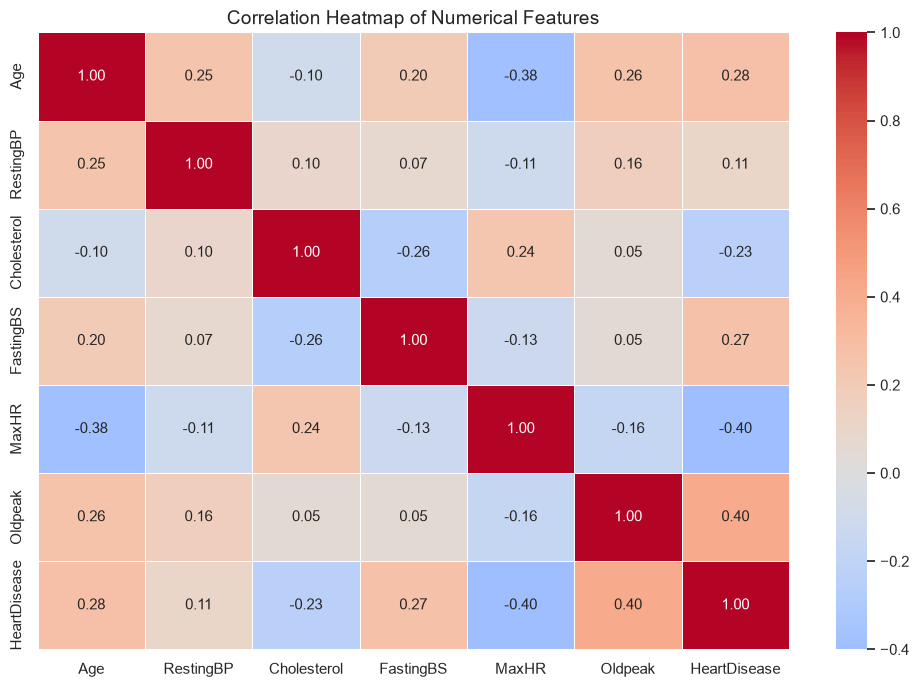

In [79]:
# Correlation heatmap for numerical variables
plt.figure(figsize=(10, 7))
corr_matrix = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
)

plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

## 5. Data Preparation and Encoding

The dataset is separated into predictors and target labels. Categorical variables are transformed using one-hot encoding, while numerical variables are kept in their numeric form.



In [80]:


X_raw = df.drop(columns=TARGET_COL)
y = df[TARGET_COL].astype(int)

X_encoded = pd.get_dummies(X_raw, drop_first=False)
X_encoded = X_encoded.replace([np.inf, -np.inf], np.nan)
X_encoded = X_encoded.fillna(X_encoded.median(numeric_only=True)).astype(float)

X_encoded.columns  = X_encoded.columns.astype(str).tolist()

feature_name_mapping = pd.DataFrame({
    "Original Feature Name": original_feature_names,
    "Safe Feature Name": X_encoded.columns,
})

X_train_p, X_test_p, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Training set: {X_train_p.shape}")
print(f"Test set: {X_test_p.shape}")
display(X_train_p.head())

Training set: (734, 20)
Test set: (184, 20)


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Sex_F,Sex_M,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
485,63.0,139.0,217.0,1.0,128.0,1.2,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
486,55.0,110.0,214.0,1.0,180.0,0.4,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
117,59.0,130.0,338.0,1.0,130.0,1.5,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
361,47.0,160.0,0.0,0.0,124.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
296,50.0,145.0,0.0,1.0,139.0,0.7,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0


## 7. Cross-Validation Model Comparison

 classification models are compared using repeated stratified cross-validation on the training set.

The primary comparison metric is **ROC-AUC**, which is suitable here because it evaluates ranking quality across classification thresholds and is less dependent on one fixed cutoff than accuracy.

In [81]:



lgbm_base = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=2,
    num_leaves=4,
    subsample=0.70,
    colsample_bytree=0.80,
    min_child_samples=20,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1, 
)

random_forest_base = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

logistic_regression_base = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

svm_base = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        probability=True,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

xgboost_base = XGBClassifier(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=2,
    subsample=0.70,
    colsample_bytree=0.80,
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

knn_base = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(
        n_neighbors=5,
        weights="distance"
    ))
])

gradient_boosting_base = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=2,
    random_state=RANDOM_STATE
)

voting_model = VotingClassifier(
    estimators=[
        ("lgbm", lgbm_base),
        ("rf", random_forest_base),
   
    ],
    voting="soft",
    n_jobs=-1,
)

models = {
    "Random Forest": random_forest_base,
    "LightGBM": lgbm_base,
    "Logistic Regression": logistic_regression_base,
    "SVM": svm_base,
    "KNN": knn_base,
    "Gradient Boosting": gradient_boosting_base,
    "Soft Voting Ensemble": voting_model,
}

,Model,Mean ROC-AUC,Std ROC-AUC
0,Soft Voting Ensemble,0.932656,0.024523
1,Random Forest,0.930153,0.025392
2,LightGBM,0.929790,0.026084
3,Gradient Boosting,0.927167,0.025602
4,Logistic Regression,0.924063,0.028452
5,SVM,0.918141,0.028841
6,KNN,0.892410,0.031052


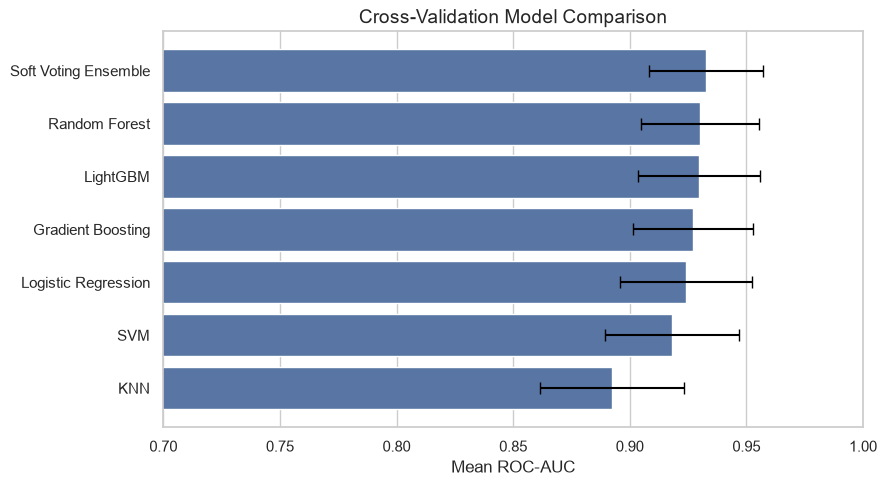

In [82]:
cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=3,
    random_state=RANDOM_STATE,
)

cv_results = []

for model_name, model in models.items():
    scores = cross_val_score(
        model,
        X_train_p,
        y_train,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1,
    )

    cv_results.append({
        "Model": model_name,
        "Mean ROC-AUC": scores.mean(),
        "Std ROC-AUC": scores.std(),
    })

cv_results_df = (
    pd.DataFrame(cv_results)
    .sort_values("Mean ROC-AUC", ascending=False)
    .reset_index(drop=True)
)

display(cv_results_df)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=cv_results_df,
    x="Mean ROC-AUC",
    y="Model",
    orient="h",
)

plt.errorbar(
    x=cv_results_df["Mean ROC-AUC"],
    y=np.arange(len(cv_results_df)),
    xerr=cv_results_df["Std ROC-AUC"],
    fmt="none",
    capsize=4,
    color="black",
)

plt.title("Cross-Validation Model Comparison")
plt.xlabel("Mean ROC-AUC")
plt.ylabel("")
plt.xlim(0.70, 1.00)
plt.tight_layout()
plt.show()

## 8. Final Model Training

The final model is a **soft-voting ensemble** that combines:

- LightGBM  
- Random Forest

Soft voting averages predicted probabilities, which often produces a more stable classifier than relying on a single model.

In [83]:
final_model = voting_model 

final_model.fit(X_train_p, y_train)

y_pred = final_model.predict(X_test_p)
y_proba = final_model.predict_proba(X_test_p)[:, 1]

print("Final model training completed.")

Final model training completed.


## 9. Test-Set Evaluation

The model is evaluated on the unseen test set using:

- Accuracy  
- ROC-AUC  
- Classification report  
- Confusion matrix  
- ROC curve  
- Precision-Recall curve  

Accuracy is useful, but ROC-AUC and Precision-Recall curves provide a more detailed view of model discrimination and threshold behavior.

In [84]:
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)
avg_precision = average_precision_score(y_test, y_proba)

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "ROC-AUC", "Average Precision"],
    "Score": [accuracy, roc_auc, avg_precision],
})

display(metrics_df)

report_df = pd.DataFrame(classification_report(y_test, y_pred, output_dict=True)).T
display(report_df)

,Metric,Score
0,Accuracy,0.923913
1,ROC-AUC,0.935916
2,Average Precision,0.933424


,precision,recall,f1-score,support
0,0.925000,0.902439,0.913580,82.000000
1,0.923077,0.941176,0.932039,102.000000
accuracy,0.923913,0.923913,0.923913,0.923913
macro avg,0.924038,0.921808,0.922810,184.000000
weighted avg,0.923934,0.923913,0.923813,184.000000


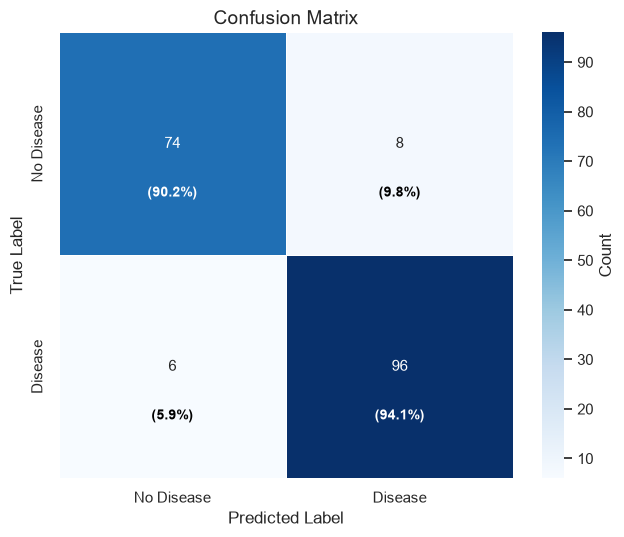

In [85]:
def plot_confusion_matrix_with_percentages(y_true, y_predicted, class_names):
    cm = confusion_matrix(y_true, y_predicted)
    cm_percent = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    plt.figure(figsize=(6.5, 5.5))
    ax = sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        linewidths=0.5,
        cbar_kws={"label": "Count"},
    )

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j + 0.5,
                i + 0.72,
                f"({cm_percent[i, j]:.1f}%)",
                ha="center",
                va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black",
                fontsize=10,
                fontweight="bold",
            )

    plt.title("Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()


plot_confusion_matrix_with_percentages(
    y_test,
    y_pred,
    class_names=["No Disease", "Disease"],
)

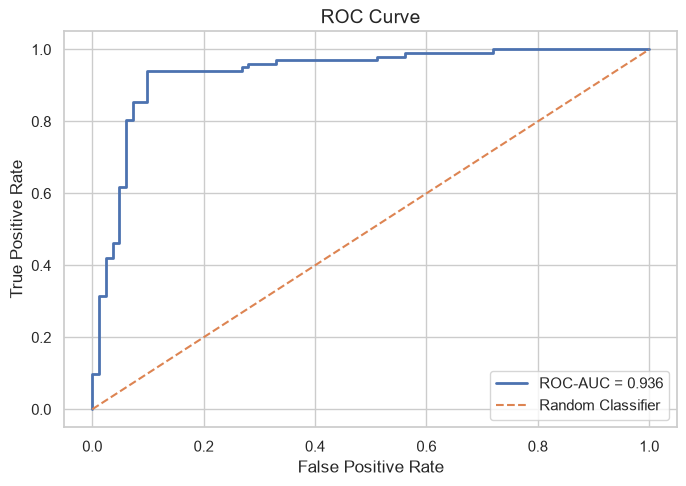

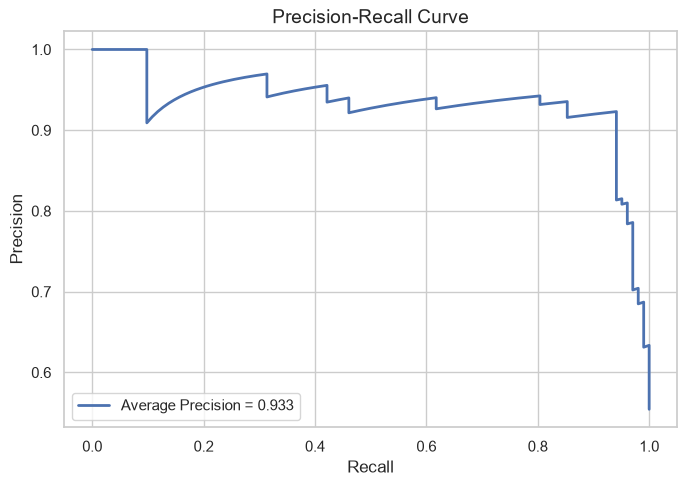

In [86]:
# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.3f}", linewidth=2)
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


# Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, label=f"Average Precision = {avg_precision:.3f}", linewidth=2)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()

## 10. Permutation Feature Importance

Permutation importance measures how much the model performance decreases when each feature is randomly shuffled.

A larger decrease means the feature is more important for the trained model's predictions.

This method is model-agnostic and is applied here to the full soft-voting ensemble.

,Feature,Importance_Mean,Importance_STD
0,ST_Slope_Up,0.031157,0.010150
1,ChestPainType_ASY,0.014016,0.007621
2,Cholesterol,0.012610,0.004986
3,Oldpeak,0.008357,0.005056
4,Sex_F,0.008122,0.004612
5,ST_Slope_Flat,0.007795,0.004697
6,FastingBS,0.007257,0.002856
7,RestingBP,0.005221,0.001887
8,ExerciseAngina_N,0.004404,0.002592
9,ExerciseAngina_Y,0.002622,0.001528


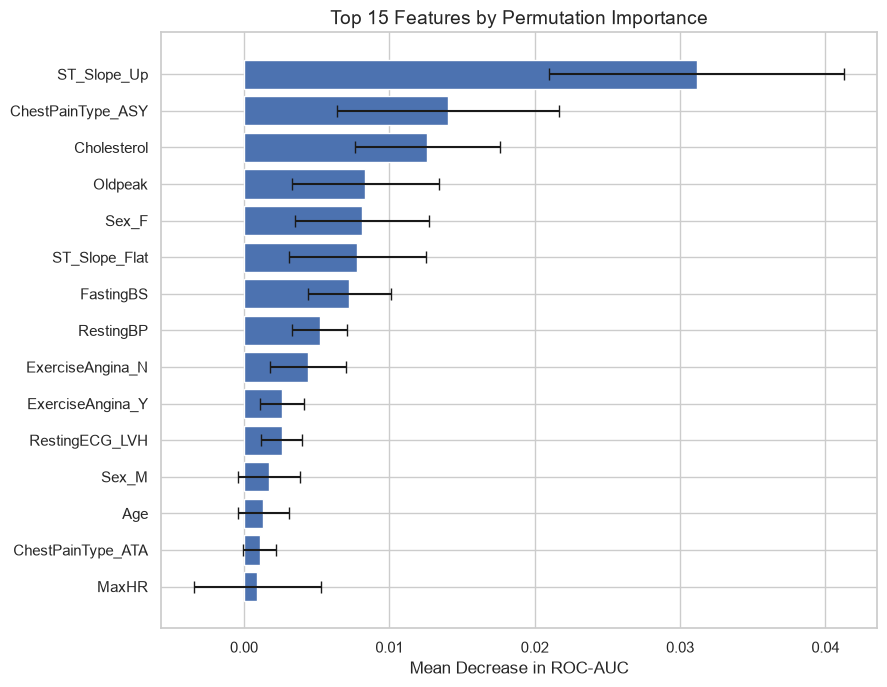

In [87]:
perm_result = permutation_importance(
    final_model,
    X_test_p,
    y_test,
    scoring="roc_auc",
    n_repeats=30,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

perm_importance_df = pd.DataFrame({
    "Feature": X_test_p.columns,
    "Importance_Mean": perm_result.importances_mean,
    "Importance_STD": perm_result.importances_std,
}).sort_values("Importance_Mean", ascending=False).reset_index(drop=True)

display(perm_importance_df.head(20))

top_perm_features = perm_importance_df.head(15).sort_values("Importance_Mean", ascending=True)

plt.figure(figsize=(9, 7))
plt.barh(
    top_perm_features["Feature"],
    top_perm_features["Importance_Mean"],
    xerr=top_perm_features["Importance_STD"],
    capsize=4,
)
plt.title("Top 15 Features by Permutation Importance")
plt.xlabel("Mean Decrease in ROC-AUC")
plt.ylabel("")
plt.tight_layout()
plt.show()

## 11. SHAP Explainability

SHAP values are used to explain how each feature contributes to both individual and global model predictions.

Since the final ensemble is based on **LightGBM** and **Random Forest**, SHAP analysis is computed for the **LightGBM component** only. LightGBM is a tree-based gradient boosting model, which makes it highly suitable for SHAP-based interpretation.

Using one representative tree-based model keeps the notebook focused, avoids redundant interpretation plots, and still provides a clear explanation of the main decision patterns learned from the data.

The SHAP section includes:

- Global feature importance bar plot  
- Beeswarm plot showing both feature importance and direction of effect  
- Waterfall plot for one example patient  
- Dependence plots for the most important features  

In SHAP beeswarm and dependence plots, the gray horizontal regions represent the distribution and spread of individual SHAP values across many observations. They are not confidence intervals or uncertainty bands.


Background dataset has 734 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=734 when initializing the masker.


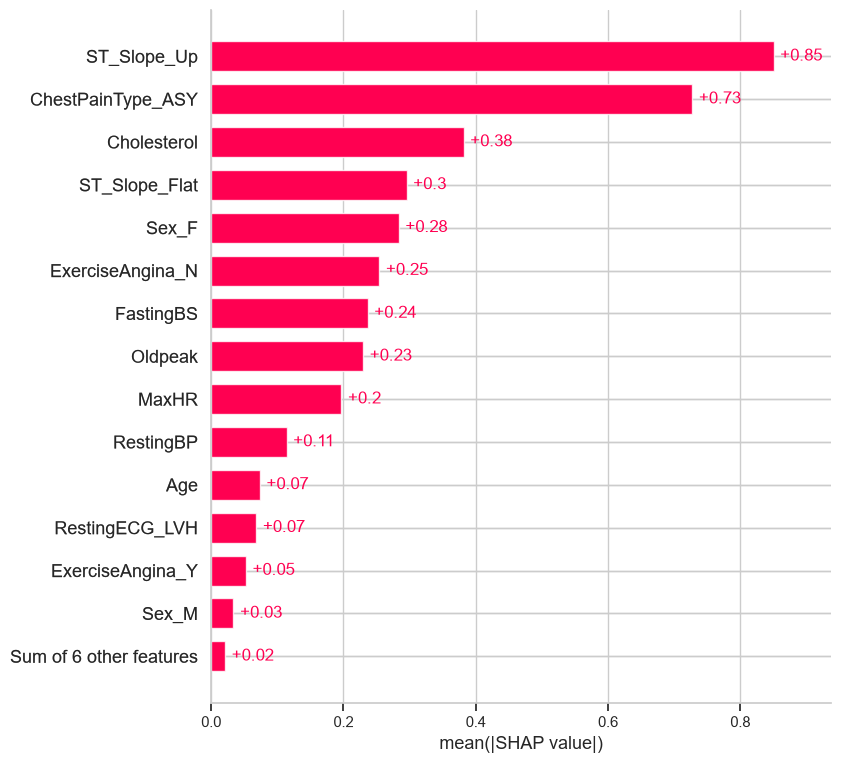

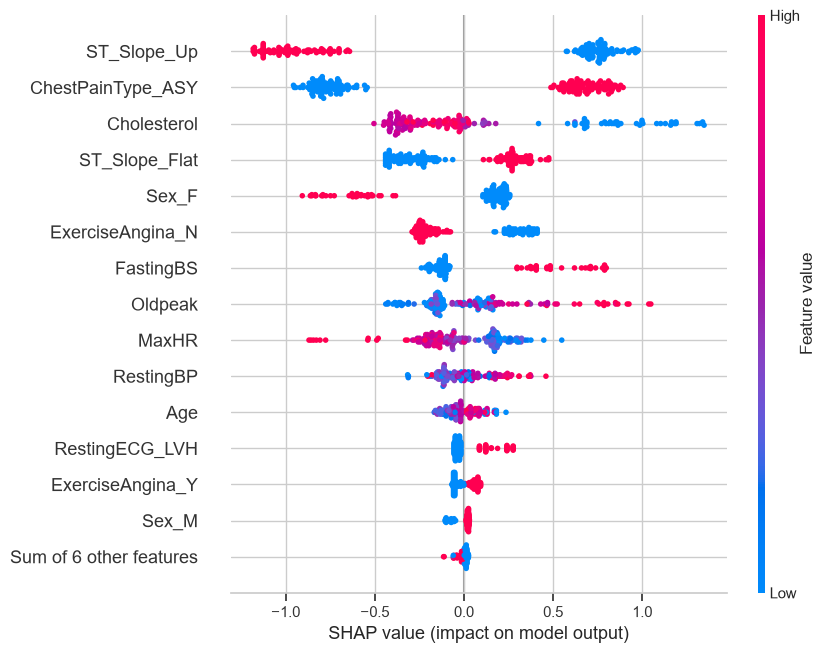

In [88]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

shap_model = final_model.named_estimators_["lgbm"]
explainer = shap.Explainer(shap_model, X_train_p)
shap_values = explainer(X_test_p)

if len(shap_values.values.shape) == 3:
    base_values_array = np.asarray(shap_values.base_values)
    if len(base_values_array.shape) == 2:
        selected_base_values = base_values_array[:, 1]
    else:
        selected_base_values = shap_values.base_values
    shap_values_lgbm = shap.Explanation(
        values=shap_values.values[:, :, 1],
        base_values=selected_base_values,
        data=shap_values.data,
        feature_names=X_test_p.columns.tolist(),
    )
else:
    shap_values_lgbm = shap_values

shap.plots.bar(shap_values_lgbm, max_display=15)
shap.plots.beeswarm(shap_values_lgbm, max_display=15)


Patient index: 0
True label: 1
Predicted probability of heart disease: 0.9476
Predicted class: 1


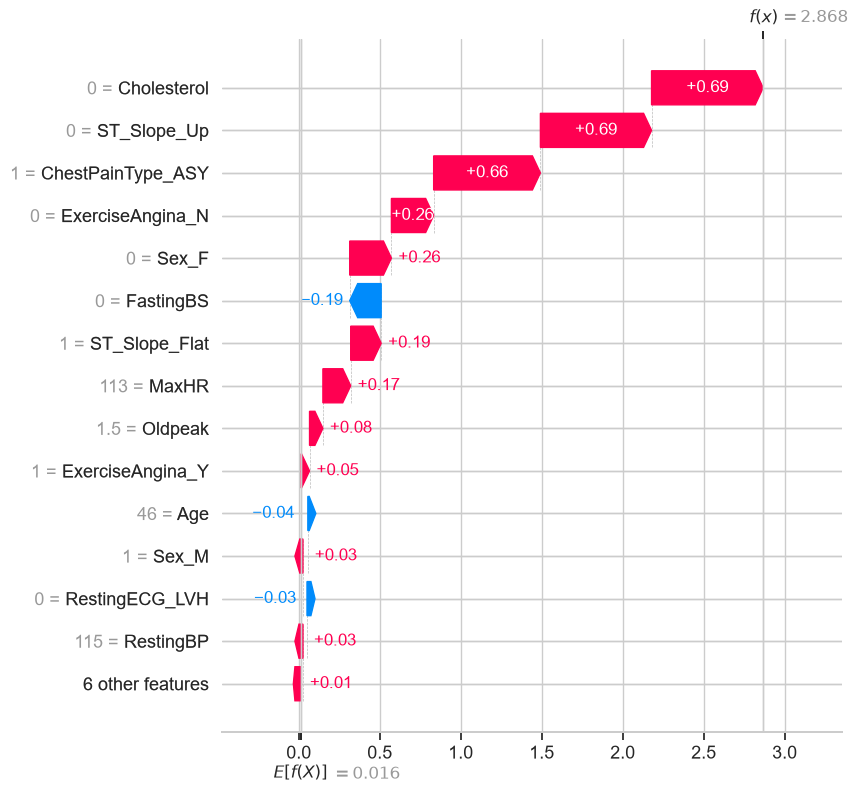

In [89]:
patient_index = 0

true_label = y_test.iloc[patient_index]
predicted_probability = y_proba[patient_index]
predicted_class = y_pred[patient_index]

print(f"Patient index: {patient_index}")
print(f"True label: {true_label}")
print(f"Predicted probability of heart disease: {predicted_probability:.4f}")
print(f"Predicted class: {predicted_class}")

shap.plots.waterfall(
    shap_values_lgbm[patient_index],
    max_display=15,
)


,Feature,Mean_ABS_SHAP
0,ST_Slope_Up,0.850281
1,ChestPainType_ASY,0.727377
2,Cholesterol,0.381599
3,ST_Slope_Flat,0.295413
4,Sex_F,0.283584
5,ExerciseAngina_N,0.254193
6,FastingBS,0.236515
7,Oldpeak,0.229718
8,MaxHR,0.196778
9,RestingBP,0.113982


Top features selected for SHAP dependence plots:
['ST_Slope_Up', 'ChestPainType_ASY', 'Cholesterol']


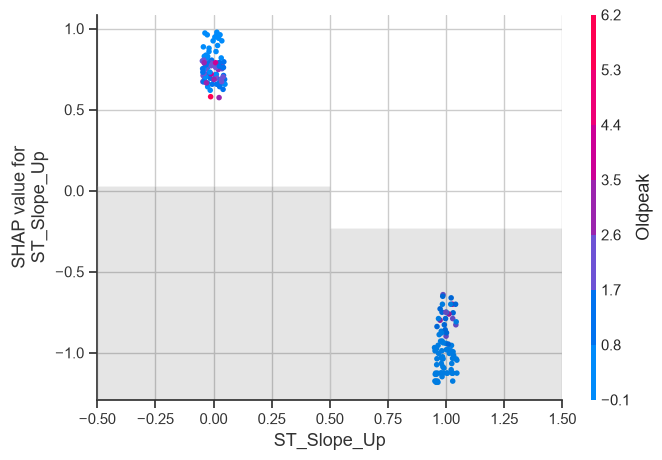

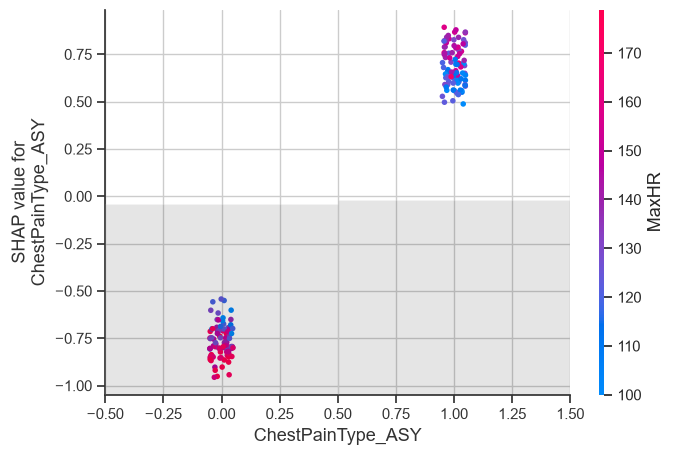

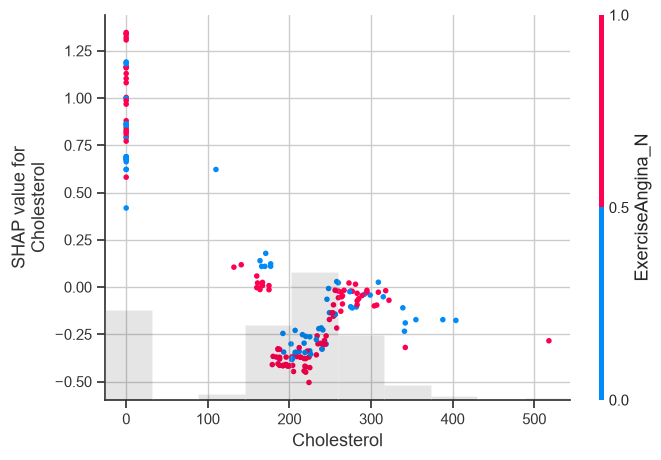

In [90]:
mean_abs_shap = np.abs(shap_values_lgbm.values).mean(axis=0)

shap_importance_df = (
    pd.DataFrame({
        "Feature": X_test_p.columns,
        "Mean_ABS_SHAP": mean_abs_shap,
    })
    .sort_values("Mean_ABS_SHAP", ascending=False)
    .reset_index(drop=True)
)

display(shap_importance_df.head(10))

top_features_for_dependence = shap_importance_df["Feature"].head(3).tolist()

print("Top features selected for SHAP dependence plots:")
print(top_features_for_dependence)

for feature in top_features_for_dependence:
    shap.plots.scatter(
        shap_values_lgbm[:, feature],
        color=shap_values_lgbm,
    )


## 12. Conclusion

This notebook developed a complete machine-learning pipeline for heart disease prediction.

Key points:

- The dataset was inspected for structure, missing values, duplicates, and target balance.  
- Additional engineered features were added without deleting the original variables.  
- Multiple classifiers were compared using repeated stratified cross-validation.  
- A soft-voting ensemble was trained as the final model.  
- The final model was evaluated using accuracy, ROC-AUC, average precision, confusion matrix, ROC curve, and Precision-Recall curve.  
- Permutation importance and SHAP were used to interpret the model's behavior.

### Limitations

The model should be interpreted as a predictive experiment, not a clinical diagnostic system. For real medical use, further validation would be required, including external validation, calibration analysis, fairness checks, and clinical review.